## Heatmap for Category by Years

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv("review-vc_sales_by_collection.csv")

In [4]:
df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


In [5]:
df['year'] = df['yr_month'].astype(str).str[:4]

## Foam Mattress

In [7]:
foam_df = df[
    (df['financial_category']=='Foam Mattresses') &
    (df['year'].isin(['2022','2023','2024']))
].copy()

In [8]:
foam_df = foam_df[foam_df['collection'] != '__TOTAL__']

In [9]:
foam_df = foam_df.dropna(subset=['written_avg_rating'])

In [10]:
foam_df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year
34,202201,Foam Mattresses,8in Ultima Foam,3.080000,11.0,25.0,0.440000,NaN,NaN,NaN,NaN,382571.39,1691.0,2022
35,202201,Foam Mattresses,8in Green Tea MF,3.476190,6.0,21.0,0.285714,NaN,NaN,NaN,NaN,565753.62,2208.0,2022
36,202201,Foam Mattresses,8in Gel Green Tea MF,3.655172,9.0,29.0,0.310345,NaN,NaN,NaN,NaN,549609.24,2144.0,2022
41,202201,Foam Mattresses,8in Cloud MF,2.000000,1.0,1.0,1.000000,NaN,NaN,NaN,NaN,62246.29,239.0,2022
42,202201,Foam Mattresses,6in Ultima Foam,1.000000,8.0,8.0,1.000000,NaN,NaN,NaN,NaN,75928.28,367.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20796,202412,Foam Mattresses,10in GT Essential MF w WonderBox,4.000000,1.0,4.0,0.250000,4.000000,1.0,4.0,0.250000,299684.94,1621.0,2024
20797,202412,Foam Mattresses,10in GT Essential MF,5.000000,0.0,3.0,0.000000,5.000000,0.0,3.0,0.000000,10803.10,58.0,2024
20801,202412,Foam Mattresses,10in Cooling Essential MF w WonderBox,3.333333,1.0,3.0,0.333333,3.333333,1.0,3.0,0.333333,580059.42,3169.0,2024
20802,202412,Foam Mattresses,10in Cooling Essential MF,5.000000,0.0,1.0,0.000000,5.000000,0.0,1.0,0.000000,10475.94,40.0,2024


In [11]:
top_cols = (
    foam_df.groupby('collection')['sales_amount']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

In [12]:
top_cols

Index(['12in Green Tea MF', '12in Gel Green Tea MF', '6in Green Tea MF',
       '10in Green Tea MF', '10in Gel Green Tea MF', '8in Gel Green Tea MF',
       '8in Green Tea MF', '12in GTMF w WonderBox', '12in MyGel w WonderBox',
       '10in GTMF w WonderBox', '12in Cloud MF', '6in GTMF w WonderBox',
       '6in Gel Green Tea MF', '8in Ultima Foam', '12in GT Essential MF',
       '12in GT Luxe MF', '10in Ultima Foam', '12in Ultra Cooling Gel MF',
       '10in Cloud MF', '10in GT Essential MF', '6in Cooling Essential MF',
       '12in Cooling Essential MF', '10in Cooling Essential MF',
       '10in MyGel w WonderBox', '8in Cooling Essential MF',
       '8in GTMF w WonderBox', '8in GT Essential MF', '5in Bunk Bed MF',
       '6in Ultima Foam', '8in MyGel w WonderBox'],
      dtype='object', name='collection')

In [13]:
foam_cols = foam_df[foam_df['collection'].isin(top_cols)].copy()

In [14]:
foam_cols['rating_bin'] = foam_cols['written_avg_rating'].round(1)

In [15]:
foam_cols['rating_bin'].min()

1.0

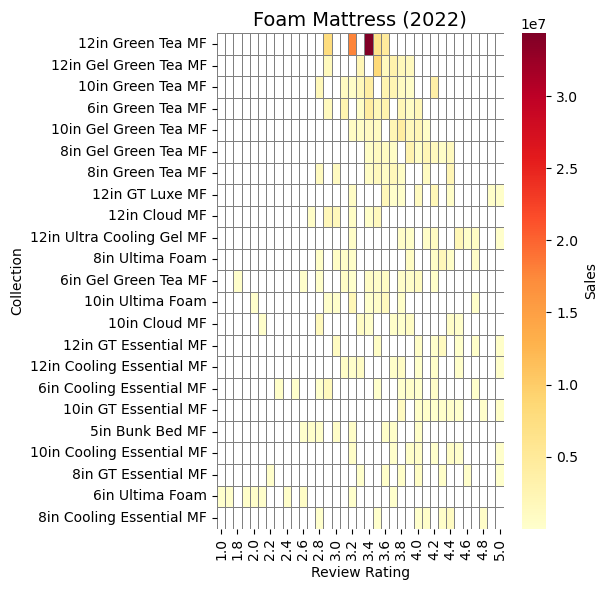

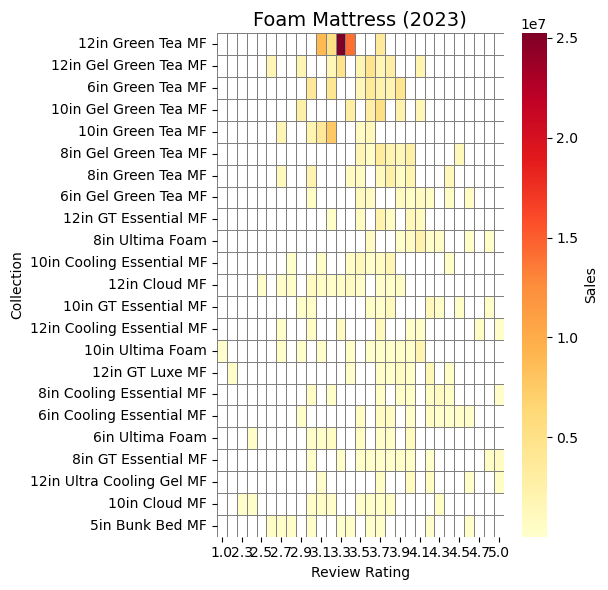

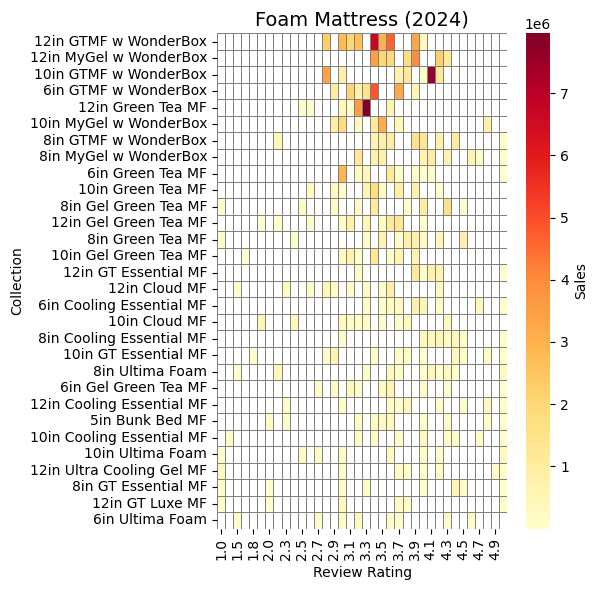

In [27]:
for year in ['2022','2023','2024']:
    pivot = (
        foam_cols[foam_cols['year']==year]
        .groupby(['collection','rating_bin'])['sales_amount']
        .sum()
        .unstack(fill_value=0)
       # .sort_index()
    )

    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    mask = pivot == 0

    plt.figure(figsize=(6,6))
    sns.heatmap(pivot, cmap='YlOrRd', mask=mask, linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Sales'})
                                                                                  
    plt.title(f'Foam Mattress ({year})', fontsize=14)
    plt.xlabel('Review Rating')
    plt.ylabel('Collection')
    plt.tight_layout()
    plt.show()
    